In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

from vs_ns_periodic_mrSAV_solver import vs_mrSAV_Vorticity_Stream_Periodic_Solver as vs_mrSAV_solver


In [7]:
# ─── Common setup ────────────────────────────────────────────────────────────
delta = 0.05   # perturbation amplitude
gam   = 1000   # mean-reversion parameter γ
T     = 1.2    # final time
s_domain = (0, 0, 1, 1)   # Ω = (0,1)×(0,1)

def no_force(X, Y, t):
    return np.zeros_like(X)

def make_initial_vorticity(rho: float, N: int) -> np.ndarray:
    """
    Returns initial vorticity ω₀ on the (N,N) interior grid
    via spectral differentiation of the double-shear-layer velocity field.
    """
    tmp = vs_mrSAV_solver(1.0, 1.0, s_domain, [N, N],
                          np.zeros((N + 1, N + 1)), no_force, "ETD_mrGSAV_MS2_b")
    x, y = tmp.X[:-1, :-1], tmp.Y[:-1, :-1]

    u = np.where(y <= 0.5, np.tanh(rho * (y - 0.25)), np.tanh(rho * (0.75 - y)))
    v = delta * np.sin(2 * np.pi * x)

    return tmp.velocity2vorticity(u, v)   # shape (N, N)



In [8]:
# rho = 100, nu = 5e-5, 256x256 modes
# dt = 6e-4  (intentionally larger than the reference step to stress-test ETD-MS2 stability)
rho_thin = 100
nu_thin  = 5e-5
N_thin   = 256

dt_thin  = 6e-4

# Store vorticity snapshots only on a sparse large-step grid for the error curve.
# This avoids keeping every 1e-4 reference state in memory.
error_stride = 5
error_dt = dt_thin * error_stride
error_sample_times = np.round(
    np.arange(0, int(np.rint(T / error_dt)) + 1, dtype=np.float64) * error_dt,
    12,
)
error_sample_times[-1] = T


def snapshot_at(solver, time, atol=1e-12):
    snapshot_t = getattr(solver, "tn_s", solver.tn)
    idx = np.flatnonzero(np.isclose(snapshot_t, time, rtol=0.0, atol=atol))
    if len(idx) == 0:
        raise ValueError(f"No saved snapshot at t={time}.")
    return solver.Omega[idx[0]]


omega0_thin     = make_initial_vorticity(rho_thin, N_thin)
omega0_thin_pad = np.pad(omega0_thin, ((0, 1), (0, 1)))

# ETDRK4 reference with tau = 1e-4. The saved snapshots align with the large-step grid.
solver_thin_ref = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "ETDRK4")
solver_thin_ref.solve_fix_step((0, T), dt_thin / 6, snapshot=error_sample_times)
omega_thin_ref_078 = snapshot_at(solver_thin_ref, 0.78)
omega_thin_ref_T = snapshot_at(solver_thin_ref, T)

solver_thin = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "ETD_mrGSAV_MS2_b")
solver_thin.solve_fix_step((0, T), dt_thin/2, snapshot=error_sample_times)
omega_thin_T = snapshot_at(solver_thin, T)

# ETD-MS2 blows up before T=1.2 at this step size. The error and enstrophy masks below
# automatically ignore non-finite states after divergence.
solver_thin_etdms2 = vs_mrSAV_solver(nu_thin, gam, s_domain, [N_thin, N_thin], omega0_thin_pad, no_force, "ETDMS2")
solver_thin_etdms2.solve_fix_step((0, T), dt_thin, snapshot=error_sample_times)
omega_thin_pre_blowup_etdms2 = snapshot_at(solver_thin_etdms2, 0.78)

# Detect blow-up time.
_valid = np.isfinite(solver_thin_etdms2.Enstrophy)
t_blowup_thin = solver_thin_etdms2.tn[np.argmax(~_valid)] if not _valid.all() else None
print(f"ETD-MS2 thin-layer blow-up time: {t_blowup_thin:.4f}" if t_blowup_thin else "ETD-MS2: no blow-up detected")




 1.200000\1.2, Elapse: 0.025 s, Vorticity Energy:0.4694, Enstrophy:57.8485, Palinstrophy:391513.2692, Maximum:77.63, |q-1|:0.0000e+00        
 1.200000\1.2, Elapse: 0.026 s, Vorticity Energy:0.4694, Enstrophy:57.8511, Palinstrophy:391533.4939, Maximum:77.63, |q-1|:6.0417e-04        
 0.830400\1.2, Elapse: 0.029 s, Vorticity Energy:41406524958880284733059062026494270637026792758925460215194727865893966298398713388078829328263328805755947849710199000772414051465164115959663373386914881966983422269028919708515627238737076353725628416.0000, Enstrophy:7683286818684170160199117738524348744844503739606631315767385862570306227242795915655704769521576310349544380255061175981126054309445772345341763434447571566696304004073572603135534125819610471364459979866112.0000, Palinstrophy:2392711107782259000193996944168325584600069371104030924444998645974934259760449203421908240275461909485180876704634793571407694067217863985470841360798450051248095726134411651873177287034213509571886809421816266752.0000

/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:154: RuntimeWarning: overflow encountered in multiply
  return self.h*np.sum(f*g)
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:135: RuntimeWarning: overflow encountered in multiply
  u_omega_x = self.ift(self.D_x * self.dealias(self.ft(u * omega_d))).real
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:136: RuntimeWarning: overflow encountered in multiply
  v_omega_y = self.ift(self.D_y * self.dealias(self.ft(v * omega_d))).real
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:138: RuntimeWarning: overflow encountered in multiply
  return -(u*omega_x + v*omega_y + u_omega_x + v_omega_y)/2
/Users/wanghaifeng/Desktop/ETD-mr-SAV-MS2/vs_ns_periodic_mrSAV_solver.py:138: RuntimeWarning: invalid value encountered in add
  return -(u*omega_x + v*omega_y + u_omega_x + v_omega_y)/2


 1.200000\1.2, Elapse: 0.026 s, Vorticity Energy:nan, Enstrophy:nan, Palinstrophy:nan, Maximum:nan, |q-1|:0.0000e+00     58455796982233644130761017086505234506590932811940147354970241566557126896973078509050529409299502282477898922918289413590322374778232066948637341635790851197249497628703973749817344.00, |q-1|:0.0000e+00     
ETD-MS2 thin-layer blow-up time: 0.8310


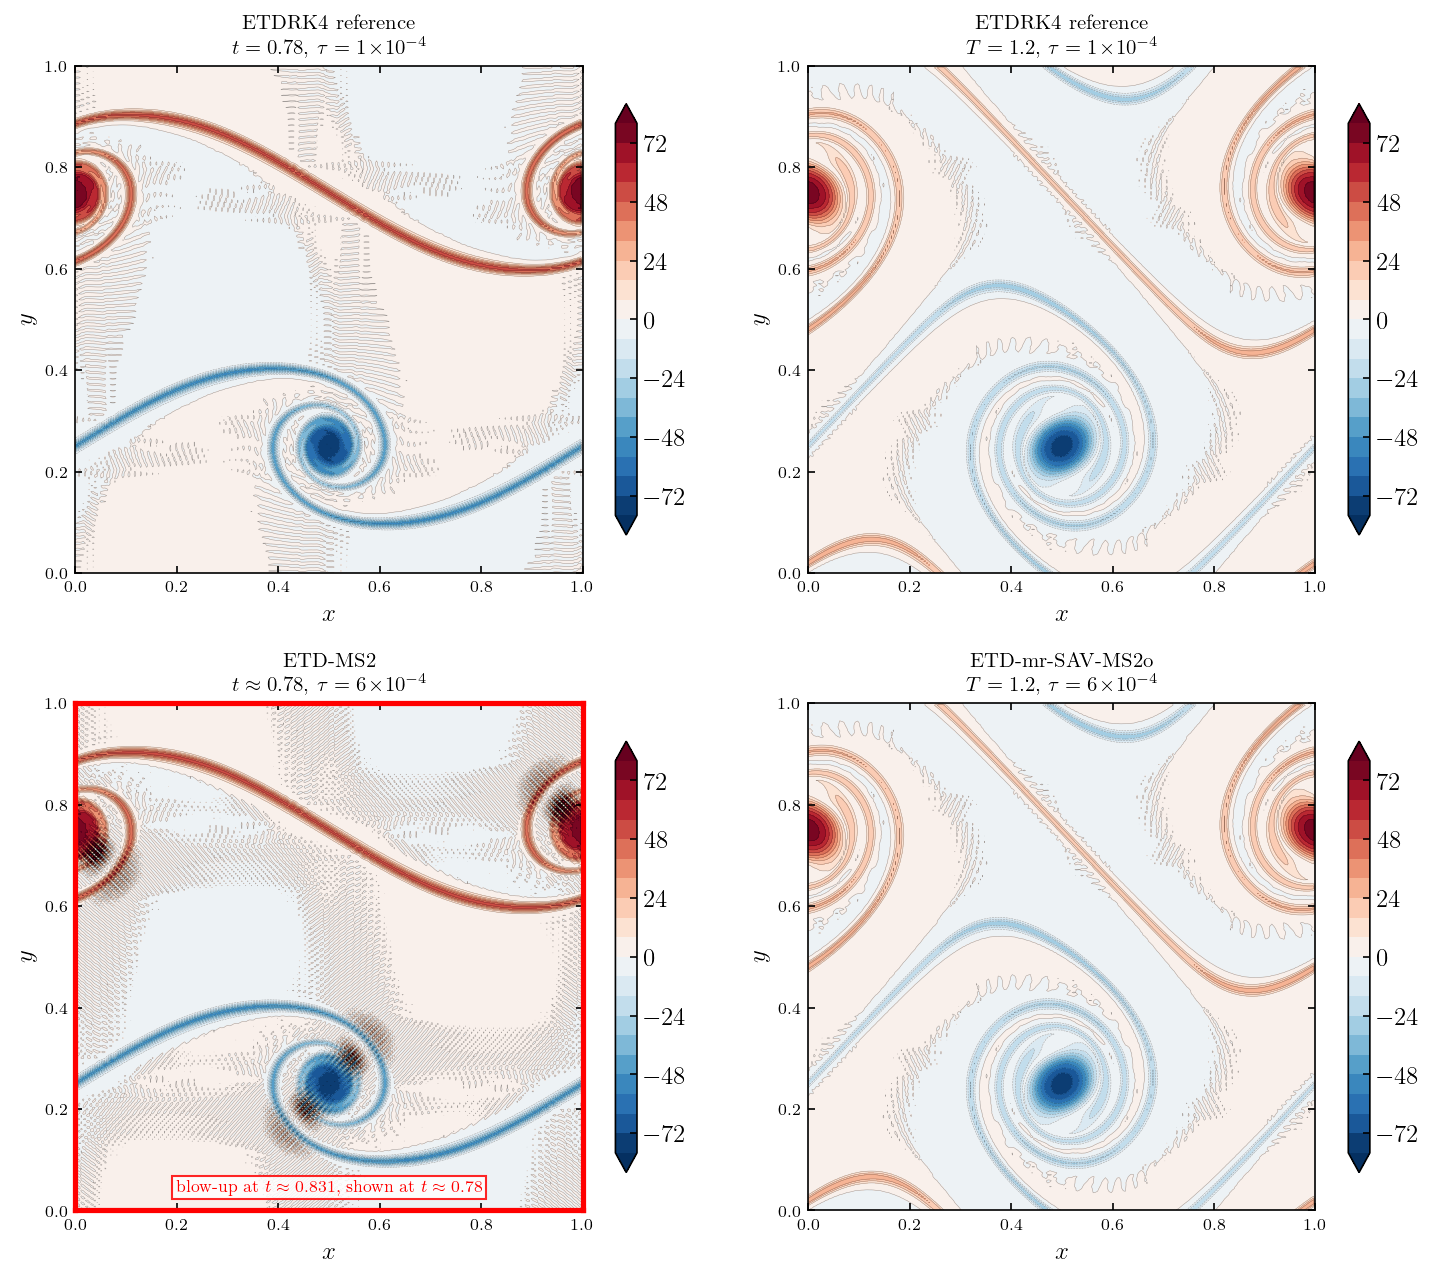

In [9]:
# Figure 1: Vorticity comparison (2x2 grid)
# Row 1 (reference): ETDRK4 with small tau = 1e-4 at t = 0.78, 1.2
# Row 2 (large tau): ETD-MS2 (pre-blowup) / ETD-mr-SAV-MS2o with tau = 6e-4

def _omega_plot(omega, N):
    Xp, Yp = np.meshgrid(np.linspace(0, 1, N + 1), np.linspace(0, 1, N + 1))
    return Xp, Yp, np.pad(omega, ((0, 1), (0, 1)))

col_titles = [
    r'ETDRK4 reference', r'ETDRK4 reference',
    r'ETD-MS2', r'ETD-mr-SAV-MS2o',
]
method_tag = [
    r'$t=0.78$, $\tau = 1\!\times\!10^{-4}$',
    r'$T=1.2$, $\tau = 1\!\times\!10^{-4}$',
    r'$t\approx 0.78$, $\tau = 6\!\times\!10^{-4}$',
    r'$T=1.2$, $\tau = 6\!\times\!10^{-4}$',
]
row_labels = [
    r'Reference ($\tau = 1\!\times\!10^{-4}$)',
    r'Large $\tau = 6\!\times\!10^{-4}$',
]

omega_panels = [
    (omega_thin_ref_078,              N_thin),
    (omega_thin_ref_T,                N_thin),
    (omega_thin_pre_blowup_etdms2,    N_thin),
    (omega_thin_T,                    N_thin),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5), dpi=150)

for row in range(2):
    vmax = 80

    for col in range(2):
        ax  = axes[row, col]
        idx = row * 2 + col
        omega, N = omega_panels[idx]
        Xp, Yp, op = _omega_plot(omega, N)

        if np.any(np.isfinite(op)):
            levels = np.linspace(-vmax, vmax, 21)
            cf = ax.contourf(Xp, Yp, op, levels=levels, cmap='RdBu_r', extend='both')
            ax.contour(Xp, Yp, op, levels=levels, colors='k', linewidths=0.25, alpha=0.35)
            plt.colorbar(cf, ax=ax, shrink=0.85)

        # ETD-MS2 panel (row=1, col=0) is the one that blows up.
        is_blowup_panel = (row == 1 and col == 0)
        if is_blowup_panel and t_blowup_thin is not None:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2.5)
            ax.text(0.5, 0.03,
                    rf'blow-up at $t\approx{t_blowup_thin:.3f}$, shown at $t\approx 0.78$',
                    ha='center', va='bottom', transform=ax.transAxes,
                    fontsize=8, color='red',
                    bbox=dict(fc='white', ec='red', lw=1, alpha=0.85, pad=2))

        ax.set_title(f'{col_titles[idx]}\n{method_tag[idx]}', fontsize=10)
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$y$')
        ax.set_aspect('equal')
        ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=8)

fig.tight_layout(pad=1., h_pad=2., w_pad=1.)
fig.savefig('fig/shear_layer_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()




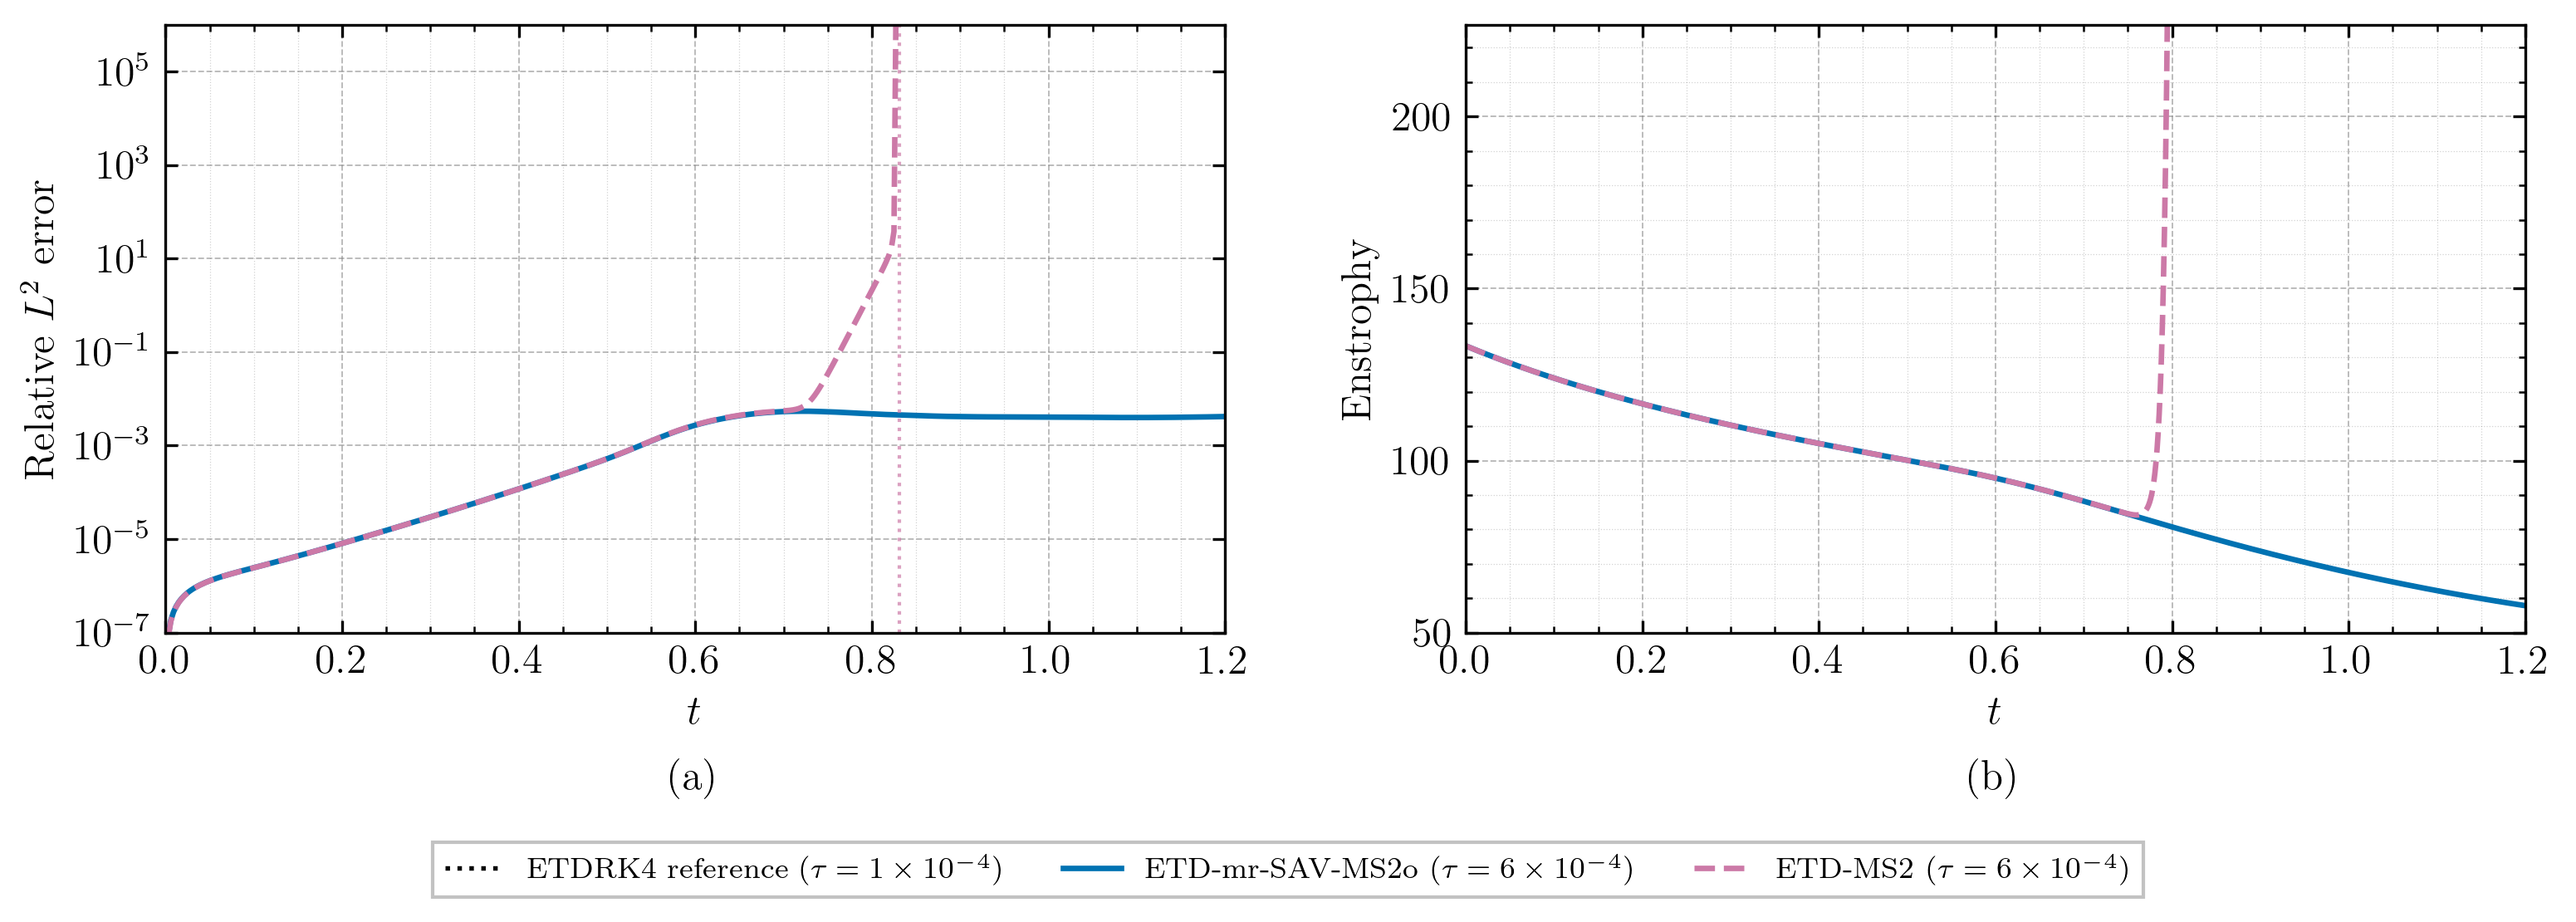

In [19]:
# Figure 2: Relative L2 error and enstrophy evolution for the thin shear layer
from matplotlib.ticker import LogLocator, AutoMinorLocator


def relative_l2_error_against_reference(metric_solver, solver, ref_solver):
    t = getattr(solver, "tn_s", solver.tn)
    ref_t = getattr(ref_solver, "tn_s", ref_solver.tn)
    if len(t) != len(ref_t) or not np.allclose(t, ref_t, rtol=0.0, atol=1e-12):
        raise ValueError("Solver and reference snapshots must be saved on the same time grid.")

    rel_err = np.full(len(t), np.nan, dtype=np.float64)
    for i, (omega, ref_omega) in enumerate(zip(solver.Omega, ref_solver.Omega)):
        if not (np.all(np.isfinite(omega)) and np.all(np.isfinite(ref_omega))):
            continue
        ref_norm = metric_solver.inner_product(ref_omega, ref_omega)
        if ref_norm <= 0:
            continue
        diff = omega - ref_omega
        rel_err[i] = np.sqrt(metric_solver.inner_product(diff, diff) / ref_norm)
    return t, rel_err


okabe_ito = {
    "orange": "#E69F00",
    "blue": "#0072B2",
    "purple": "#CC79A7",
    "black": "#000000",
}

fig, (ax_err, ax_ens) = plt.subplots(1, 2, figsize=(10.5, 4.4), dpi=300)

# Left: relative L2 error against the ETDRK4 reference.
error_configs = [
    (solver_thin,        r'ETD-mr-SAV-MS2o ($\tau=6\times10^{-4}$)', okabe_ito["blue"],   '-',  1.6),
    (solver_thin_etdms2, r'ETD-MS2 ($\tau=6\times10^{-4}$)',        okabe_ito["purple"], '--', 1.6),
]

for solver, label, color, ls, lw in error_configs:
    t_err, rel_err = relative_l2_error_against_reference(solver_thin_ref, solver, solver_thin_ref)
    mask = np.isfinite(rel_err) & (rel_err > 0)
    if ls == "-": rel_err[mask] = rel_err[mask] * 4  # Slight vertical offset for better visibility
    ax_err.semilogy(t_err[mask], rel_err[mask], color=color, linestyle=ls, linewidth=lw, label=label)

if t_blowup_thin is not None:
    ax_err.axvline(t_blowup_thin, color=okabe_ito["purple"], linestyle=':',
                   linewidth=1.0, alpha=0.7)

ax_err.set_xlim(0, T)
ax_err.set_xlabel(r'$t$')
ax_err.set_ylim(1e-7, 1e6)
ax_err.set_ylabel(r'Relative $L^2$ error')
ax_err.yaxis.set_major_locator(LogLocator(base=10))
# Right: enstrophy history.
enstrophy_configs = [
    (solver_thin_ref,    r'ETDRK4 reference ($\tau=1\times10^{-4}$)', okabe_ito["black"],  ':',  1.3, True),
    (solver_thin,        r'ETD-mr-SAV-MS2o ($\tau=6\times10^{-4}$)',  okabe_ito["blue"],   '-',  1.6, True),
    (solver_thin_etdms2, r'ETD-MS2 ($\tau=6\times10^{-4}$)',          okabe_ito["purple"], '--', 1.6, False),
]

y_stable_max = 0.0
for solver, label, color, ls, lw, stable in enstrophy_configs:
    t = solver.tn
    ens = solver.Enstrophy
    mask = np.isfinite(ens)
    ax_ens.plot(t[mask], ens[mask], color=color, linestyle=ls,
                linewidth=lw, label=label)
    if stable and mask.any():
        y_stable_max = max(y_stable_max, np.max(ens[mask]))

ax_ens.set_xlim(0, T)
ax_ens.set_ylim(50, y_stable_max * 1.7)

# if t_blowup_thin is not None:
#     ax_ens.axvline(t_blowup_thin, color=okabe_ito["purple"], linestyle=':',
#                    linewidth=1.0, alpha=0.7)
#     ax_ens.annotate(rf'blow-up $t\approx{t_blowup_thin:.3f}$',
#                     xy=(t_blowup_thin, ax_ens.get_ylim()[1] * .8),
#                     xytext=(-8, 0), textcoords='offset points',
#                     color=okabe_ito["purple"], fontsize=8.5,
#                     va='top', ha='left')

ax_ens.set_xlabel(r'$t$')
ax_ens.set_ylabel(r'Enstrophy')
for ax, panel in zip((ax_err, ax_ens), (r'(a)', r'(b)')):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which='major', ls='--', lw=0.45, alpha=0.55, color='gray')
    ax.grid(True, which='minor', ls=':',  lw=0.3,  alpha=0.35, color='gray')
    ax.text(0.5, -0.24, panel, transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='center', va='center')

ax_ens.yaxis.set_minor_locator(AutoMinorLocator())

handles_by_label = {}
for ax in (ax_err, ax_ens):
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        handles_by_label.setdefault(label, handle)

legend_order = [
    r'ETDRK4 reference ($\tau=1\times10^{-4}$)',
    r'ETD-mr-SAV-MS2o ($\tau=6\times10^{-4}$)',
    r'ETD-MS2 ($\tau=6\times10^{-4}$)',
]
legend_handles = [handles_by_label[label] for label in legend_order if label in handles_by_label]
legend_labels = [label for label in legend_order if label in handles_by_label]
fig.legend(legend_handles, legend_labels, fontsize=8.5, loc='lower center',
           bbox_to_anchor=(0.5, 0.15), ncol=3, framealpha=0.95, edgecolor='0.75', fancybox=False)

fig.tight_layout(rect=(0, 0.16, 1, 1), w_pad=2.2)
fig.savefig('fig/shear_layer_error_enstrophy.pdf', bbox_inches='tight', dpi=300)
plt.show()


\begin{exm}\label{exm:shear_layer}[Double shear layer]
In this example, we consider the double shear layer problem on $\Omega = (0,1)^2$ with viscosity $\nu = 5\times 10^{-5}$ and final time $T = 1.2$. The initial velocity field is prescribed as
\begin{equation*}
u_0(x,y) = \begin{cases} \tanh\!\bigl(\rho(y - \tfrac{1}{4})\bigr), & y \le \tfrac{1}{2}, \\[4pt] \tanh\!\bigl(\rho(\tfrac{3}{4} - y)\bigr), & y > \tfrac{1}{2}, \end{cases} \qquad v_0(x,y) = \delta \sin(2\pi x),
\end{equation*}
with $\rho = 100$ and $\delta = 0.05$, and the initial vorticity $\omega_0$ is obtained from the velocity field via spectral differentiation. No external forcing is applied ($f = 0$). The Reynolds number, $\mathrm{Re} := \|\bm{u}_0\|/\nu \approx 1.96\times 10^4$, is computed from the $L^2$ norm of the initial velocity $\|\bm{u}_0\| \approx 0.98$, placing the flow firmly in the convection-dominated regime. For spatial discretization, $256$ Fourier modes are used.
\end{exm}

We set the mean-reverting parameter $\gamma = 1000$ and $\tilde{\gamma} = 0.1$. To test stability under a relatively large time step, we compare ETD-mr-SAV-MS2o and ETD-MS2 with $\tau = 6\times 10^{-4}$. The ETDRK4 solution computed with the finer time step $\tau = 1\times 10^{-4}$ is used as the reference. The vorticity contours at selected time instances are shown in Figure~\ref{fig:shear_vorticity}.

From Figure~\ref{fig:shear_vorticity}, we observe that the double shear layer develops thin, rolling vortex structures as the flow evolves. The reference solution captures the roll-up and thinning of the shear layers at representative times. With the larger step size $\tau = 6\times 10^{-4}$, ETD-mr-SAV-MS2o produces vorticity fields that remain in close agreement with the reference solution up to $T = 1.2$. In contrast, ETD-MS2 suffers numerical blow-up before the final time; the displayed ETD-MS2 panel shows the last valid state before divergence.

Figure~\ref{fig:shear_error_enstrophy} further quantifies this behavior. The relative $L^2$ error is measured against the ETDRK4 reference on the saved large-step time grid, while the enstrophy is monitored over the full time integration. ETD-mr-SAV-MS2o maintains a bounded error and follows the reference enstrophy evolution through the final time, whereas ETD-MS2 shows a rapid loss of accuracy followed by a blow-up in enstrophy. These results show that the mean-reverting SAV formulation improves robustness for convection-dominated flows with thin vorticity layers, allowing a larger time step while preserving the coherent vortex structures observed in the reference solution.

\begin{figure}[htbp]
\centering
\includegraphics[width=0.75\linewidth]{fig/shear_layer_comparison.pdf}
\caption{Vorticity contours for the double shear layer with $\rho = 100$ and $\nu = 5\times 10^{-5}$. Top row: reference ETDRK4 solution computed with $\tau = 1\times 10^{-4}$. Bottom row: ETD-MS2 before blow-up and ETD-mr-SAV-MS2o with $\tau = 6\times 10^{-4}$. The ETD-MS2 panel is marked to indicate the loss of stability before the final time.}
\label{fig:shear_vorticity}
\end{figure}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.95\linewidth]{fig/shear_layer_error_enstrophy.pdf}
\caption{Temporal diagnostics for the double shear layer. (a) Relative $L^2$ error of the large-step solutions with respect to the ETDRK4 reference. (b) Enstrophy evolution for the reference solution, ETD-mr-SAV-MS2o, and ETD-MS2. The vertical dotted line marks the detected blow-up time of ETD-MS2.}
\label{fig:shear_error_enstrophy}
\end{figure}


